In [1]:
!pip uninstall -y torch torchvision torchaudio
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
!pip install -q facenet-pytorch gdown transformers timm scikit-learn seaborn accelerate opencv-python pillow

Found existing installation: torch 2.2.2
Uninstalling torch-2.2.2:
  Successfully uninstalled torch-2.2.2
Found existing installation: torchvision 0.17.2
Uninstalling torchvision-0.17.2:
  Successfully uninstalled torchvision-0.17.2
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.9/657.9 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 29.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 66.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 231.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 74.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 162.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 88.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB

# EEEM068 Applied Machine Learning — MSCTD Emotion/Sentiment Recognition Project

**Project goal:** three-class sentiment classification (`negative`, `neutral`, `positive`) using the **MSCTD En-De** dataset.

This notebook implements a complete pipeline:

1. Dataset download and parsing from the official MSCTD repository.
2. Dataset exploration and class distribution plots.
3. Face extraction using MTCNN.
4. Face-based CNN/transfer-learning classifier.
5. Robustness evaluation using degraded/distorted face images.
6. Augmentation-aware retraining.
7. Full-image frozen-backbone model.
8. Fusion model using face probabilities + full-image probabilities + number of detected faces.
9. Extra-credit multimodal model using text + image fusion with Transformer-style text features.

> **Important:** For a 4-hour run, keep `FAST_MODE = True`. For the final/max-marks run, set `FAST_MODE = False`, increase epochs, and run overnight/with Colab GPU.


In [2]:
FAST_MODE = True
# =========================
# 0. Runtime check
# =========================
import os, sys, subprocess, platform, time, random, math, json, shutil, glob, re
from pathlib import Path

print("Python:", sys.version)
print("Platform:", platform.platform())

try:
    import torch
    print("Torch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
except Exception as e:
    print("Torch import issue:", e)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Torch: 2.2.2+cu121
CUDA available: True
GPU: Tesla T4


In [3]:
import torch, torchvision
print("Dependencies installed.")
# =========================
# 1. Install dependencies
# =========================
# facenet-pytorch = MTCNN face detection
# gdown = Google Drive download
# transformers = text Transformer models
# timm = optional modern vision backbones

!pip -q install facenet-pytorch gdown transformers timm scikit-learn seaborn accelerate

# Fix for "partially initialized module 'torchvision' has no attribute 'extension'"
# This error often occurs due to torchvision version incompatibility or installation issues.
# Explicitly uninstalling and reinstalling torchvision can resolve it.
!pip uninstall -y torchvision
!pip install torchvision==0.16.0

Dependencies installed.
Found existing installation: torchvision 0.17.2
Uninstalling torchvision-0.17.2:
  Successfully uninstalled torchvision-0.17.2
ERROR: Ignored the following yanked versions: 0.1.6, 0.1.7, 0.1.8, 0.1.9, 0.2.0, 0.2.1, 0.2.2, 0.2.2.post2, 0.2.2.post3
ERROR: Could not find a version that satisfies the requirement torchvision==0.16.0 (from versions: 0.17.0, 0.17.1, 0.17.2, 0.18.0, 0.18.1, 0.19.0, 0.19.1, 0.20.0, 0.20.1, 0.21.0, 0.22.0, 0.22.1, 0.23.0, 0.24.0, 0.24.1, 0.25.0, 0.26.0)
ERROR: No matching distribution found for torchvision==0.16.0


In [4]:
# =========================
# 2. Imports and configuration
# =========================
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance, ImageFilter
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T
import torchvision.models as models

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from facenet_pytorch import MTCNN
from transformers import AutoTokenizer, AutoModel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# -------------------------
# Main switches
# -------------------------
FAST_MODE = True   # True = practical 4-hour version. False = fuller/max-marks run.
RUN_FACE_EXTRACTION = True
RUN_FACE_MODEL = True
RUN_AUGMENTATION_EXPERIMENT = True
RUN_FULL_IMAGE_MODEL = True
RUN_FUSION_MODEL = True
RUN_MULTIMODAL_EXTRA_CREDIT = True

# To save time, start with subset; increase for final.
if FAST_MODE:
    MAX_TRAIN = 3500
    MAX_VAL = 800
    MAX_TEST = 1000
    FACE_EPOCHS = 3
    FACE_AUG_EPOCHS = 3
    IMAGE_EPOCHS = 3
    FUSION_EPOCHS = 8
    MULTIMODAL_EPOCHS = 3
else:
    MAX_TRAIN = None
    MAX_VAL = None
    MAX_TEST = None
    FACE_EPOCHS = 8
    FACE_AUG_EPOCHS = 8
    IMAGE_EPOCHS = 8
    FUSION_EPOCHS = 15
    MULTIMODAL_EPOCHS = 5

BATCH_SIZE = 32
IMG_SIZE = 224
NUM_CLASSES = 3

LABEL_MAP = {0: "neutral", 1: "negative", 2: "positive"}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

PROJECT_DIR = Path("/content/eeem068_msctd_project")
REPO_DIR = PROJECT_DIR / "MSCTD"
DATA_DIR = PROJECT_DIR / "data"
IMAGE_DIR = DATA_DIR / "images"
CACHE_DIR = PROJECT_DIR / "cache"
FACE_DIR = CACHE_DIR / "faces"
MODEL_DIR = PROJECT_DIR / "models"
RESULT_DIR = PROJECT_DIR / "results"

for p in [PROJECT_DIR, DATA_DIR, IMAGE_DIR, CACHE_DIR, FACE_DIR, MODEL_DIR, RESULT_DIR]:
    p.mkdir(parents=True, exist_ok=True)


Device: cuda


## Dataset download

The official repository contains the text/sentiment/index files. The image ZIPs are hosted on Google Drive.

Drive file IDs used here:

- `train_ende.zip`: `1GAZgPpTUBSfhne-Tp0GDkvSHuq6EMMbj`
- `dev.zip`: `12HM8uVNjFg-HRZ15ADue4oLGFAYQwvTA`
- `test.zip`: `1B9ZFmSTqfTMaqJ15nQDrRNLqBvo-B39W`

If Google Drive quota blocks download, manually download the ZIPs and place them in `/content/eeem068_msctd_project/data/images/`.


In [5]:
# =========================
# 3. Clone official MSCTD repo and download images
# =========================
%cd /content

if not REPO_DIR.exists():
    !git clone https://github.com/XL2248/MSCTD.git {REPO_DIR}
else:
    print("Repo already exists:", REPO_DIR)

# Download image ZIPs from the official links in the repo README.
# If Drive quota fails, manually download and upload to Colab, then put zip files into IMAGE_DIR.

DRIVE_FILES = {
    "train_ende.zip": "1GAZgPpTUBSfhne-Tp0GDkvSHuq6EMMbj",
    "dev.zip": "12HM8uVNjFg-HRZ15ADue4oLGFAYQwvTA",
    "test.zip": "1B9ZFmSTqfTMaqJ15nQDrRNLqBvo-B39W",
}

for fname, fid in DRIVE_FILES.items():
    out = IMAGE_DIR / fname
    if not out.exists():
        print("Downloading", fname)
        !gdown --id {fid} -O {out}
    else:
        print("Already downloaded:", out)

# Unzip all image files.
for zip_path in IMAGE_DIR.glob("*.zip"):
    out_folder = IMAGE_DIR / zip_path.stem
    if not out_folder.exists():
        out_folder.mkdir(parents=True, exist_ok=True)
        print("Unzipping", zip_path.name)
        !unzip -q {zip_path} -d {out_folder}
    else:
        print("Already unzipped:", out_folder)


/content
Cloning into '/content/eeem068_msctd_project/MSCTD'...
remote: Enumerating objects: 1268, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 1268 (delta 44), reused 9 (delta 3), pack-reused 1190 (from 1)
Receiving objects: 100% (1268/1268), 102.52 MiB | 11.05 MiB/s, done.
Resolving deltas: 100% (648/648), done.
Updating files: 100% (914/914), done.
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1GAZgPpTUBSfhne-Tp0GDkvSHuq6EMMbj
From (redirected): https://drive.google.com/uc?id=1GAZgPpTUBSfhne-Tp0GDkvSHuq6EMMbj&confirm=t&uuid=48dae92c-5e44-45a5-b3dc-2bcc6188f775
To: /content/eeem068_msctd_project/data/images/train_ende.zip
100% 2.90G/2.90G [00:44<00:00, 65.0MB/s]
/usr/local/lib/pyth

In [16]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path("/content/eeem068_msctd_project")
REPO_DIR = PROJECT_DIR / "MSCTD"

def read_lines(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    with open(path, "r", encoding="utf-8") as f:
        return [line.rstrip("\n") for line in f]

def find_file(split, file_type):
    """
    Finds MSCTD En-De files without relying on one fixed folder name.
    split: train/dev/test
    file_type: img_index, sentiment, english
    """
    split = split.lower()

    patterns = {
        "img_index": [
            f"img_index_{split}.txt",
            f"*img*index*{split}*.txt",
            f"*image*index*{split}*.txt",
        ],
        "sentiment": [
            f"sentiment_{split}.txt",
            f"*sentiment*{split}*.txt",
        ],
        "english": [
            f"english_{split}.txt",
            f"*english*{split}*.txt",
            f"*en*{split}*.txt",
            f"*{split}*en*.txt",
        ],
    }

    candidates = []
    for pattern in patterns[file_type]:
        candidates.extend(list(REPO_DIR.rglob(pattern)))

    candidates = [p for p in candidates if p.is_file()]

    preferred = [
        p for p in candidates
        if "ende" in str(p).lower()
        or "en-de" in str(p).lower()
        or "en_de" in str(p).lower()
        or "msctd_data" in str(p).lower()
    ]

    final_candidates = preferred if preferred else candidates

    if not final_candidates:
        raise FileNotFoundError(
            f"Could not find {file_type} file for split={split}. "
            f"Check the MSCTD repo folder structure."
        )

    chosen = sorted(final_candidates, key=lambda x: len(str(x)))[0]
    print(f"Using {file_type} {split}: {chosen}")
    return chosen

def build_split_df(split):
    img_index_path = find_file(split, "img_index")
    sentiment_path = find_file(split, "sentiment")
    english_path = find_file(split, "english")

    img_indices = read_lines(img_index_path)
    sentiments = read_lines(sentiment_path)
    english_texts = read_lines(english_path)

    n = min(len(img_indices), len(sentiments), len(english_texts))

    df = pd.DataFrame({
    "split": split,
    "text_en": english_texts[:n],
    "img_index": img_indices[:n],
    "img_id": img_indices[:n],
    "label": [int(x.strip()) for x in sentiments[:n]],
})

    label_map = {
        0: "neutral",
        1: "negative",
        2: "positive",
    }

    df["label_name"] = df["label"].map(label_map)

    return df

train_df = build_split_df("train")
val_df = build_split_df("dev")
test_df = build_split_df("test")
train_df["text"] = train_df["text_en"]
val_df["text"] = val_df["text_en"]
test_df["text"] = test_df["text_en"]

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTraining label distribution:")
print(train_df["label_name"].value_counts())

Using img_index train: /content/eeem068_msctd_project/MSCTD/MSCTD_data/enzh/image_index_train.txt
Using sentiment train: /content/eeem068_msctd_project/MSCTD/MSCTD_data/enzh/sentiment_train.txt
Using english train: /content/eeem068_msctd_project/MSCTD/MSCTD_data/enzh/english_train.txt
Using img_index dev: /content/eeem068_msctd_project/MSCTD/MSCTD_data/enzh/image_index_dev.txt
Using sentiment dev: /content/eeem068_msctd_project/MSCTD/MSCTD_data/enzh/sentiment_dev.txt
Using english dev: /content/eeem068_msctd_project/MSCTD/MSCTD_data/enzh/english_dev.txt
Using img_index test: /content/eeem068_msctd_project/MSCTD/MSCTD_data/enzh/image_index_test.txt
Using sentiment test: /content/eeem068_msctd_project/MSCTD/MSCTD_data/enzh/sentiment_test.txt
Using english test: /content/eeem068_msctd_project/MSCTD/MSCTD_data/enzh/english_test.txt
Train: (13749, 7)
Validation: (504, 7)
Test: (509, 7)

Training label distribution:
label_name
neutral     5367
negative    4543
positive    3839
Name: count, d

In [17]:
# =========================
# 5. Locate image paths
# =========================
# Build image lookup by split and image ID. This is intentionally robust because zip folder names may vary.

def collect_jpgs(root):
    return list(Path(root).rglob("*.jpg")) + list(Path(root).rglob("*.jpeg")) + list(Path(root).rglob("*.png"))

all_imgs = collect_jpgs(IMAGE_DIR)
print("Total image files found:", len(all_imgs))
print("Example files:", all_imgs[:5])

def infer_split_from_path(path):
    s = str(path).lower()
    if "train" in s:
        return "train"
    if "dev" in s or "valid" in s or "val" in s:
        return "dev"
    if "test" in s:
        return "test"
    return "unknown"

lookup = {"train": {}, "dev": {}, "test": {}, "unknown": {}}
for p in all_imgs:
    stem = Path(p).stem
    if stem.isdigit():
        split_guess = infer_split_from_path(p)
        lookup[split_guess][int(stem)] = str(p)

import ast
import pandas as pd
from pathlib import Path

# Keep this the same as your notebook image directory
IMAGE_DIR = Path("/content/eeem068_msctd_project/data/images")

all_image_files = list(IMAGE_DIR.rglob("*.jpg"))
print("Total image files found:", len(all_image_files))
print("Example files:", all_image_files[:5])

def parse_img_id(img_id):
    """
    Converts MSCTD image index into a single image ID.
    Handles:
    - 123
    - "123"
    - "[0, 1, 2]"
    """
    if pd.isna(img_id):
        return None

    if isinstance(img_id, int):
        return img_id

    img_id = str(img_id).strip()

    if img_id.startswith("[") and img_id.endswith("]"):
        try:
            ids = ast.literal_eval(img_id)
            if isinstance(ids, list) and len(ids) > 0:
                return int(ids[0])
        except Exception:
            return None

    try:
        return int(img_id)
    except Exception:
        return None


def find_image_path(split, img_id):
    img_id = parse_img_id(img_id)

    if img_id is None:
        return None

    for sp in [split, "unknown", "train", "dev", "test"]:
        possible_paths = [
            IMAGE_DIR / sp / f"{img_id}.jpg",
            IMAGE_DIR / sp / sp / f"{img_id}.jpg",
            IMAGE_DIR / f"{img_id}.jpg",
        ]

        for p in possible_paths:
            if p.exists():
                return str(p)

    return None


for df in [train_df, val_df, test_df]:
    df["image_path"] = [
        find_image_path(s, i)
        for s, i in zip(df["split"], df["img_id"])
    ]
    print(df["split"].iloc[0], "missing images:", df["image_path"].isna().sum(), "/", len(df))

train_df = train_df.dropna(subset=["image_path"]).reset_index(drop=True)
val_df = val_df.dropna(subset=["image_path"]).reset_index(drop=True)
test_df = test_df.dropna(subset=["image_path"]).reset_index(drop=True)

print("After removing missing images:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

for df in [train_df, val_df, test_df]:
    df["image_path"] = [find_image_path(s, i) for s, i in zip(df["split"], df["img_id"])]
    print(df["split"].iloc[0], "missing images:", df["image_path"].isna().sum(), "/", len(df))

# Drop rows where image is missing.
train_df = train_df.dropna(subset=["image_path"]).reset_index(drop=True)
val_df = val_df.dropna(subset=["image_path"]).reset_index(drop=True)
test_df = test_df.dropna(subset=["image_path"]).reset_index(drop=True)

# Optional subset for fast runs; stratified sample.
def stratified_limit(df, max_n):
    if max_n is None or len(df) <= max_n:
        return df.reset_index(drop=True)
    return df.groupby("label", group_keys=False).apply(
        lambda x: x.sample(max(1, int(max_n * len(x) / len(df))), random_state=SEED)
    ).sample(frac=1, random_state=SEED).reset_index(drop=True)

train_df = stratified_limit(train_df, MAX_TRAIN)
val_df = stratified_limit(val_df, MAX_VAL)
test_df = stratified_limit(test_df, MAX_TEST)

print("Final sizes:", train_df.shape, val_df.shape, test_df.shape)
display(train_df.head())


Total image files found: 30370
Example files: [PosixPath('/content/eeem068_msctd_project/data/images/dev/dev/2767.jpg'), PosixPath('/content/eeem068_msctd_project/data/images/dev/dev/3796.jpg'), PosixPath('/content/eeem068_msctd_project/data/images/dev/dev/1369.jpg'), PosixPath('/content/eeem068_msctd_project/data/images/dev/dev/2341.jpg'), PosixPath('/content/eeem068_msctd_project/data/images/dev/dev/336.jpg')]
Total image files found: 30370
Example files: [PosixPath('/content/eeem068_msctd_project/data/images/dev/dev/2767.jpg'), PosixPath('/content/eeem068_msctd_project/data/images/dev/dev/3796.jpg'), PosixPath('/content/eeem068_msctd_project/data/images/dev/dev/1369.jpg'), PosixPath('/content/eeem068_msctd_project/data/images/dev/dev/2341.jpg'), PosixPath('/content/eeem068_msctd_project/data/images/dev/dev/336.jpg')]
train missing images: 13233 / 13749
dev missing images: 0 / 504
test missing images: 0 / 509
After removing missing images:
Train: (516, 8)
Validation: (504, 8)
Test: (

,split,text_en,img_index,img_id,label,label_name,text,image_path
0,train,That's why I'm here.,"[0, 1, 2, 3, 4, 5, 6]","[0, 1, 2, 3, 4, 5, 6]",2,positive,That's why I'm here.,/content/eeem068_msctd_project/data/images/dev...
1,train,We want to take you into protective custody.,"[7, 8, 9, 10, 11, 12, 13, 14]","[7, 8, 9, 10, 11, 12, 13, 14]",2,positive,We want to take you into protective custody.,/content/eeem068_msctd_project/data/images/dev...
2,train,Why don't you come out and talk to me?,"[15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]","[15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]",1,negative,Why don't you come out and talk to me?,/content/eeem068_msctd_project/data/images/dev...
3,train,You all right?,"[27, 28, 29, 30, 31, 32, 33, 34, 35]","[27, 28, 29, 30, 31, 32, 33, 34, 35]",2,positive,You all right?,/content/eeem068_msctd_project/data/images/dev...
4,train,Are we good?,"[36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]","[36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]",2,positive,Are we good?,/content/eeem068_msctd_project/data/images/dev...


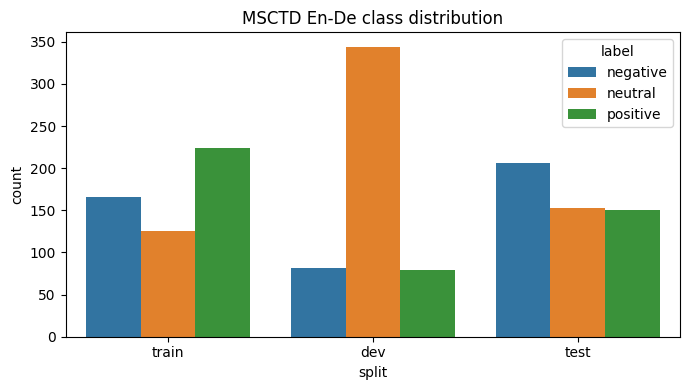

,split,label,count
0,train,negative,166
1,train,neutral,126
2,train,positive,224
3,dev,negative,81
4,dev,neutral,344
5,dev,positive,79
6,test,negative,206
7,test,neutral,153
8,test,positive,150


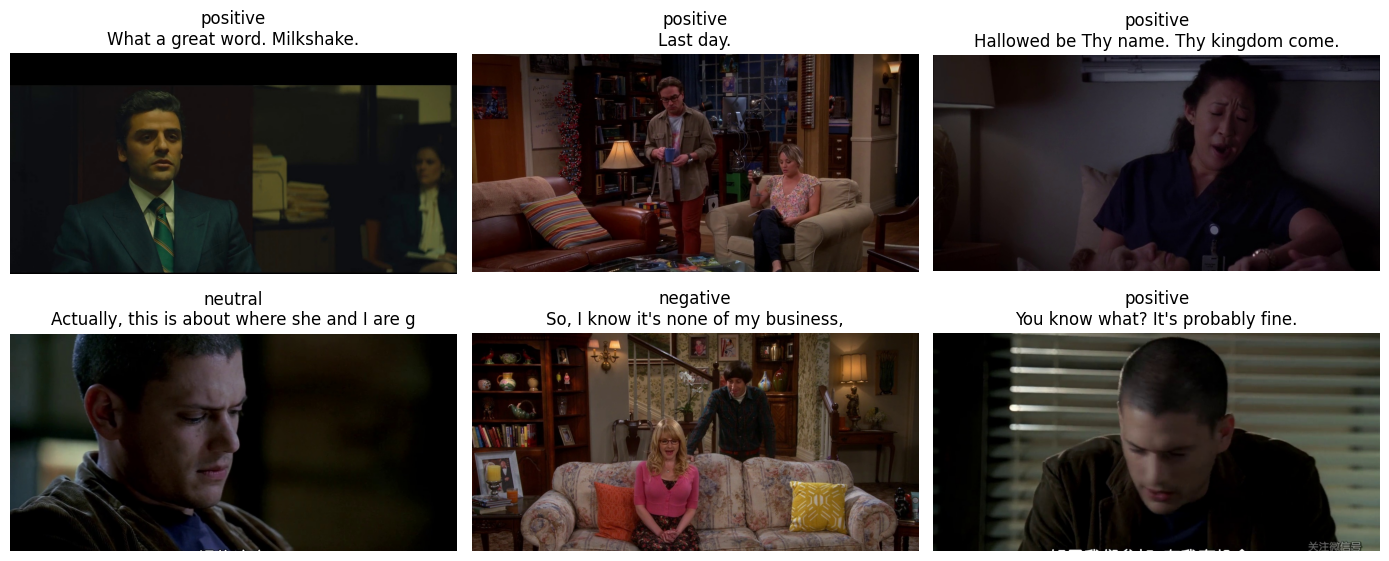

In [18]:
# =========================
# 6. Dataset visualisation
# =========================
def plot_class_distribution(dfs, names):
    rows = []
    for df, name in zip(dfs, names):
        counts = df["label_name"].value_counts().reindex(["negative","neutral","positive"]).fillna(0)
        for label, count in counts.items():
            rows.append({"split": name, "label": label, "count": count})
    dist = pd.DataFrame(rows)
    plt.figure(figsize=(7,4))
    sns.barplot(data=dist, x="split", y="count", hue="label")
    plt.title("MSCTD En-De class distribution")
    plt.tight_layout()
    out = RESULT_DIR / "class_distribution.png"
    plt.savefig(out, dpi=200)
    plt.show()
    return dist

dist_table = plot_class_distribution([train_df, val_df, test_df], ["train","dev","test"])
display(dist_table)

def show_random_images(df, n=6):
    sample = df.sample(min(n, len(df)), random_state=SEED)
    plt.figure(figsize=(14,6))
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        img = Image.open(row.image_path).convert("RGB")
        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.title(f"{row.label_name}\n{row.text_en[:45]}")
        plt.axis("off")
    plt.tight_layout()
    out = RESULT_DIR / "sample_images.png"
    plt.savefig(out, dpi=200)
    plt.show()

show_random_images(train_df, 6)


## Face extraction

This section detects and crops faces using MTCNN. It saves:

- largest detected face crop,
- number of detected faces,
- whether face detection succeeded.

This keeps the later face-based model fast.


In [19]:
# =========================
# 7. Face extraction and cache
# =========================
mtcnn = MTCNN(keep_all=True, device=DEVICE, post_process=False)

def crop_largest_face(img, boxes, margin=0.15):
    w, h = img.size
    if boxes is None or len(boxes) == 0:
        return None
    areas = []
    for b in boxes:
        x1, y1, x2, y2 = b
        areas.append(max(0, x2-x1) * max(0, y2-y1))
    b = boxes[int(np.argmax(areas))]
    x1, y1, x2, y2 = b
    bw, bh = x2-x1, y2-y1
    x1 = max(0, int(x1 - margin*bw))
    y1 = max(0, int(y1 - margin*bh))
    x2 = min(w, int(x2 + margin*bw))
    y2 = min(h, int(y2 + margin*bh))
    return img.crop((x1,y1,x2,y2))

def extract_faces_for_df(df, split):
    out_dir = FACE_DIR / split
    out_dir.mkdir(parents=True, exist_ok=True)
    records = []
    meta_path = CACHE_DIR / f"face_meta_{split}.csv"
    if meta_path.exists():
        print("Loading cached face metadata:", meta_path)
        return pd.read_csv(meta_path)

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Extract faces {split}"):
        img_path = row["image_path"]
        try:
            img = Image.open(img_path).convert("RGB")
            boxes, probs = mtcnn.detect(img)
            n_faces = 0 if boxes is None else len(boxes)
            face = crop_largest_face(img, boxes) if n_faces > 0 else None

            if face is not None:
                face = face.resize((IMG_SIZE, IMG_SIZE))
                face_path = out_dir / f"{idx}.jpg"
                face.save(face_path, quality=95)
                has_face = 1
            else:
                face_path = None
                has_face = 0

            records.append({
                "split": split,
                "orig_index": idx,
                "text": row["text_en"], # Changed 'text' to 'text_en'
                "label": int(row["label"]),
                "label_name": row["label_name"],
                "img_id": row["img_id"],
                "image_path": img_path,
                "face_path": str(face_path) if face_path else None,
                "has_face": has_face,
                "n_faces": int(n_faces)
            })
        except Exception as e:
            records.append({
                "split": split,
                "orig_index": idx,
                "text": row["text_en"], # Changed 'text' to 'text_en'
                "label": int(row["label"]),
                "label_name": row["label_name"],
                "img_id": row["img_id"],
                "image_path": img_path,
                "face_path": None,
                "has_face": 0,
                "n_faces": 0,
                "error": str(e)
            })
    meta = pd.DataFrame(records)
    meta.to_csv(meta_path, index=False)
    return meta

if RUN_FACE_EXTRACTION:
    face_train_df = extract_faces_for_df(train_df, "train")
    face_val_df = extract_faces_for_df(val_df, "dev")
    face_test_df = extract_faces_for_df(test_df, "test")
else:
    face_train_df = pd.read_csv(CACHE_DIR / "face_meta_train.csv")
    face_val_df = pd.read_csv(CACHE_DIR / "face_meta_dev.csv")
    face_test_df = pd.read_csv(CACHE_DIR / "face_meta_test.csv")

print("Face detected train:", face_train_df["has_face"].mean())
print("Face detected dev:", face_val_df["has_face"].mean())
print("Face detected test:", face_test_df["has_face"].mean())
display(face_train_df.head())

Extract faces train:   0%|          | 0/516 [00:00<?, ?it/s]

Extract faces dev:   0%|          | 0/504 [00:00<?, ?it/s]

Extract faces test:   0%|          | 0/509 [00:00<?, ?it/s]

Face detected train: 0.8585271317829457
Face detected dev: 0.8849206349206349
Face detected test: 0.8664047151277013


,split,orig_index,text,label,label_name,img_id,image_path,face_path,has_face,n_faces
0,train,0,That's why I'm here.,2,positive,"[0, 1, 2, 3, 4, 5, 6]",/content/eeem068_msctd_project/data/images/dev...,/content/eeem068_msctd_project/cache/faces/tra...,1,1
1,train,1,We want to take you into protective custody.,2,positive,"[7, 8, 9, 10, 11, 12, 13, 14]",/content/eeem068_msctd_project/data/images/dev...,/content/eeem068_msctd_project/cache/faces/tra...,1,1
2,train,2,Why don't you come out and talk to me?,1,negative,"[15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]",/content/eeem068_msctd_project/data/images/dev...,/content/eeem068_msctd_project/cache/faces/tra...,1,2
3,train,3,You all right?,2,positive,"[27, 28, 29, 30, 31, 32, 33, 34, 35]",/content/eeem068_msctd_project/data/images/dev...,/content/eeem068_msctd_project/cache/faces/tra...,1,1
4,train,4,Are we good?,2,positive,"[36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]",/content/eeem068_msctd_project/data/images/dev...,/content/eeem068_msctd_project/cache/faces/tra...,1,1


In [20]:
# =========================
# 8. Common training utilities
# =========================
def get_transforms(train=True):
    if train:
        return T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(8),
            T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
            T.ToTensor(),
            T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ])
    else:
        return T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.ToTensor(),
            T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ])

class ImageSentimentDataset(Dataset):
    def __init__(self, df, path_col="image_path", transform=None, require_existing=True):
        self.df = df.copy().reset_index(drop=True)
        self.path_col = path_col
        self.transform = transform
        if require_existing:
            self.df = self.df[self.df[path_col].notna()].reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row[self.path_col]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = int(row["label"])
        return img, label

def make_weighted_sampler(df):
    labels = df["label"].values
    class_counts = np.bincount(labels, minlength=NUM_CLASSES)
    weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = weights[labels]
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

def build_resnet_classifier(backbone_name="resnet18", frozen=False):
    if backbone_name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
        in_f = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.35),
            nn.Linear(in_f, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, NUM_CLASSES)
        )
    elif backbone_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        in_f = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.35),
            nn.Linear(in_f, 512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(512, NUM_CLASSES)
        )
    else:
        raise ValueError(backbone_name)

    if frozen:
        for name, p in model.named_parameters():
            if not name.startswith("fc."):
                p.requires_grad = False
    return model.to(DEVICE)

def train_model(model, train_loader, val_loader, epochs, lr=2e-4, weight_decay=1e-4, model_name="model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=weight_decay)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))
    best_f1 = -1
    history = []
    best_path = MODEL_DIR / f"{model_name}.pt"

    for epoch in range(1, epochs+1):
        model.train()
        train_losses, train_preds, train_labels = [], [], []
        for x, y in tqdm(train_loader, desc=f"{model_name} epoch {epoch}/{epochs} train"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_losses.append(loss.item())
            train_preds.extend(logits.argmax(1).detach().cpu().numpy())
            train_labels.extend(y.detach().cpu().numpy())

        val_metrics = evaluate_model(model, val_loader, verbose=False)
        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "train_acc": accuracy_score(train_labels, train_preds),
            "train_f1": f1_score(train_labels, train_preds, average="macro"),
            "val_acc": val_metrics["accuracy"],
            "val_f1": val_metrics["macro_f1"],
        }
        history.append(row)
        print(row)

        if row["val_f1"] > best_f1:
            best_f1 = row["val_f1"]
            torch.save(model.state_dict(), best_path)
            print("Saved best:", best_path)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(RESULT_DIR / f"{model_name}_history.csv", index=False)
    return model, hist_df

@torch.no_grad()
def evaluate_model(model, loader, verbose=True, model_name="model", save_cm=True):
    model.eval()
    probs, preds, labels = [], [], []
    for x, y in tqdm(loader, desc=f"Evaluate {model_name}"):
        x = x.to(DEVICE)
        logits = model(x)
        p = torch.softmax(logits, dim=1).detach().cpu().numpy()
        probs.append(p)
        preds.extend(p.argmax(axis=1))
        labels.extend(y.numpy())
    probs = np.vstack(probs)
    labels = np.array(labels)
    preds = np.array(preds)
    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "probs": probs,
        "preds": preds,
        "labels": labels,
    }
    if verbose:
        print("Accuracy:", metrics["accuracy"])
        print("Macro F1:", metrics["macro_f1"])
        print(classification_report(labels, preds, target_names=[LABEL_MAP[i] for i in range(NUM_CLASSES)]))
    if save_cm:
        cm = confusion_matrix(labels, preds, labels=[0,1,2])
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=[LABEL_MAP[i] for i in range(NUM_CLASSES)],
                    yticklabels=[LABEL_MAP[i] for i in range(NUM_CLASSES)])
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Confusion matrix: {model_name}")
        plt.tight_layout()
        plt.savefig(RESULT_DIR / f"{model_name}_confusion_matrix.png", dpi=200)
        plt.show()
    return metrics

def plot_history(hist_df, model_name):
    plt.figure(figsize=(7,4))
    plt.plot(hist_df["epoch"], hist_df["train_acc"], label="train_acc")
    plt.plot(hist_df["epoch"], hist_df["val_acc"], label="val_acc")
    plt.plot(hist_df["epoch"], hist_df["train_f1"], label="train_f1")
    plt.plot(hist_df["epoch"], hist_df["val_f1"], label="val_f1")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(model_name)
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f"{model_name}_training_curve.png", dpi=200)
    plt.show()


Face dataset sizes: 443 446 441


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


face_resnet18 epoch 1/3 train:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluate model:   0%|          | 0/14 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7beef86c4900>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1479, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1462, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7beef86c4900>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1479, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 14

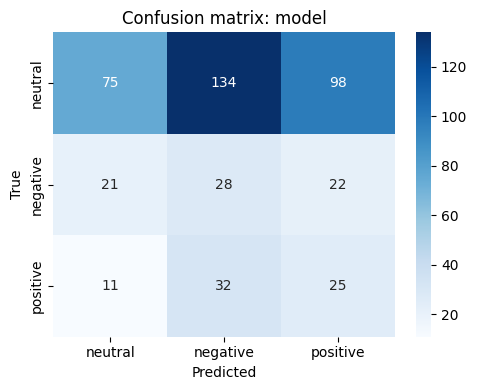

{'epoch': 1, 'train_loss': 1.1127391372408186, 'train_acc': 0.3860045146726862, 'train_f1': 0.38600339068458517, 'val_acc': 0.28699551569506726, 'val_f1': 0.26946045977808336}
Saved best: /content/eeem068_msctd_project/models/face_resnet18.pt


face_resnet18 epoch 2/3 train:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluate model:   0%|          | 0/14 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7beef86c4900>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1479, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1462, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7beef86c4900>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1479, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 14

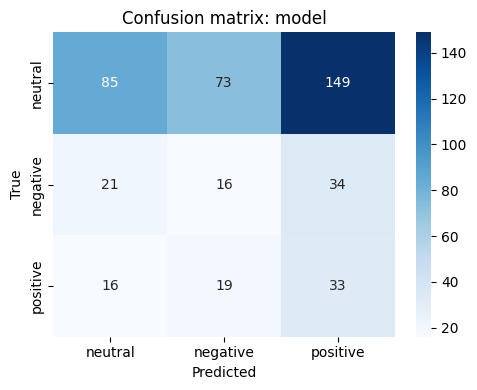

{'epoch': 2, 'train_loss': 1.0379419667380196, 'train_acc': 0.44243792325056436, 'train_f1': 0.43979422910280785, 'val_acc': 0.3004484304932735, 'val_f1': 0.26914523739608326}


face_resnet18 epoch 3/3 train:   0%|          | 0/14 [00:00<?, ?it/s]

Evaluate model:   0%|          | 0/14 [00:00<?, ?it/s]

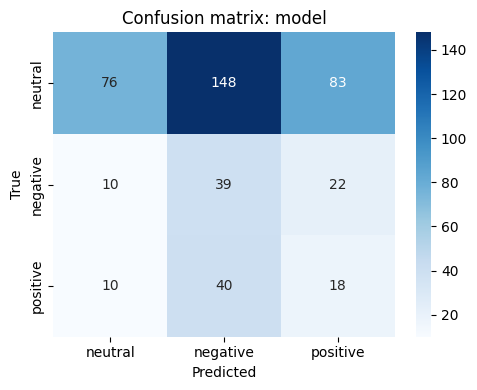

{'epoch': 3, 'train_loss': 0.9143657599176679, 'train_acc': 0.5801354401805869, 'train_f1': 0.578329149242876, 'val_acc': 0.2982062780269058, 'val_f1': 0.27579928590550545}
Saved best: /content/eeem068_msctd_project/models/face_resnet18.pt


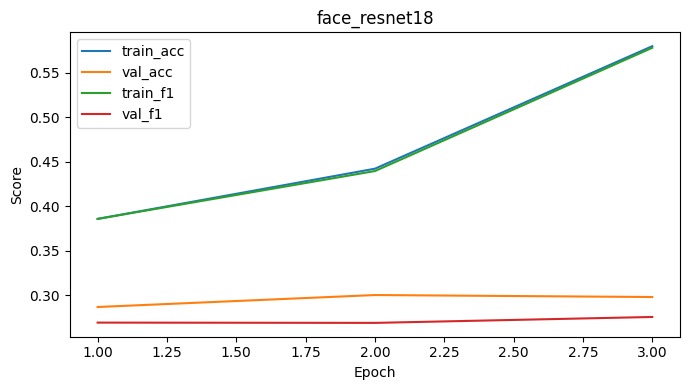

Evaluate face_resnet18:   0%|          | 0/14 [00:00<?, ?it/s]

Accuracy: 0.36961451247165533
Macro F1: 0.34686836435214224
              precision    recall  f1-score   support

     neutral       0.34      0.23      0.27       130
    negative       0.42      0.53      0.47       177
    positive       0.30      0.29      0.30       134

    accuracy                           0.37       441
   macro avg       0.35      0.35      0.35       441
weighted avg       0.36      0.37      0.36       441



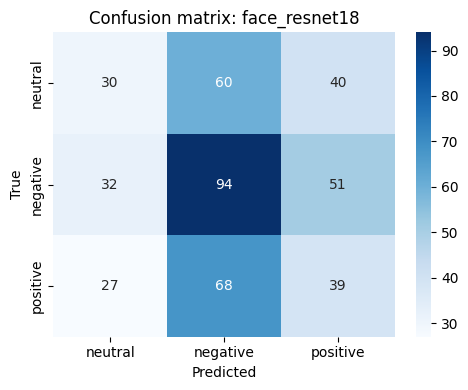

In [21]:
# =========================
# 9. Part 1: Face-based model
# =========================
face_train_clean = face_train_df[face_train_df["has_face"] == 1].reset_index(drop=True)
face_val_clean = face_val_df[face_val_df["has_face"] == 1].reset_index(drop=True)
face_test_clean = face_test_df[face_test_df["has_face"] == 1].reset_index(drop=True)

print("Face dataset sizes:", len(face_train_clean), len(face_val_clean), len(face_test_clean))

if RUN_FACE_MODEL and len(face_train_clean) > 0:
    face_train_ds = ImageSentimentDataset(face_train_clean, path_col="face_path", transform=get_transforms(True))
    face_val_ds = ImageSentimentDataset(face_val_clean, path_col="face_path", transform=get_transforms(False))
    face_test_ds = ImageSentimentDataset(face_test_clean, path_col="face_path", transform=get_transforms(False))

    face_train_loader = DataLoader(face_train_ds, batch_size=BATCH_SIZE, sampler=make_weighted_sampler(face_train_clean),
                                   num_workers=2, pin_memory=True)
    face_val_loader = DataLoader(face_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    face_test_loader = DataLoader(face_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    face_model = build_resnet_classifier("resnet18", frozen=False)
    face_model, face_hist = train_model(face_model, face_train_loader, face_val_loader,
                                        epochs=FACE_EPOCHS, lr=2e-4, model_name="face_resnet18")
    plot_history(face_hist, "face_resnet18")
    face_metrics = evaluate_model(face_model, face_test_loader, model_name="face_resnet18")
else:
    print("Skipping face model.")


## Part 2: Degraded-data robustness

This creates degraded versions of face crops and evaluates whether the original model is robust.


Degrade test faces:   0%|          | 0/441 [00:00<?, ?it/s]

Degrade train faces:   0%|          | 0/443 [00:00<?, ?it/s]

Original face model on degraded test data:


Evaluate face_resnet18_on_degraded:   0%|          | 0/14 [00:00<?, ?it/s]

Accuracy: 0.3401360544217687
Macro F1: 0.3083770065791937
              precision    recall  f1-score   support

     neutral       0.31      0.16      0.21       130
    negative       0.39      0.53      0.45       177
    positive       0.26      0.26      0.26       134

    accuracy                           0.34       441
   macro avg       0.32      0.32      0.31       441
weighted avg       0.33      0.34      0.32       441



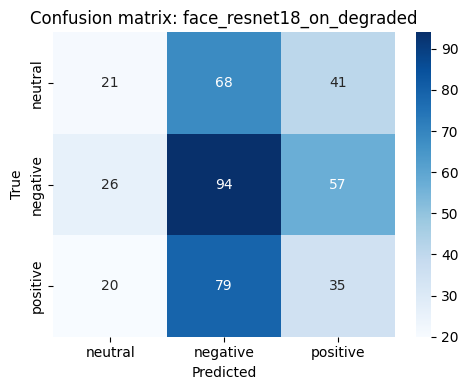

In [22]:
# =========================
# 10. Part 2: create degraded face images
# =========================
def degrade_image(img):
    # Apply one random degradation category.
    choice = random.choice(["brightness_low", "brightness_high", "blur", "noise", "jpeg", "rotate"])
    if choice == "brightness_low":
        return ImageEnhance.Brightness(img).enhance(0.45)
    if choice == "brightness_high":
        return ImageEnhance.Brightness(img).enhance(1.6)
    if choice == "blur":
        return img.filter(ImageFilter.GaussianBlur(radius=random.uniform(1.2, 2.5)))
    if choice == "noise":
        arr = np.array(img).astype(np.float32)
        noise = np.random.normal(0, 22, arr.shape)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        return Image.fromarray(arr)
    if choice == "jpeg":
        # approximate frequency/compression degradation
        tmp = CACHE_DIR / "_tmp_jpeg.jpg"
        img.save(tmp, quality=random.randint(8, 25))
        return Image.open(tmp).convert("RGB")
    if choice == "rotate":
        return img.rotate(random.uniform(-14, 14), resample=Image.BILINEAR, fillcolor=(0,0,0))
    return img

def make_degraded_faces(df, split):
    out_dir = FACE_DIR / f"{split}_degraded"
    out_dir.mkdir(parents=True, exist_ok=True)
    recs = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Degrade {split} faces"):
        src = row["face_path"]
        if pd.isna(src) or not Path(src).exists():
            continue
        out = out_dir / f"{idx}.jpg"
        if not out.exists():
            img = Image.open(src).convert("RGB")
            deg = degrade_image(img).resize((IMG_SIZE, IMG_SIZE))
            deg.save(out, quality=90)
        r = row.to_dict()
        r["face_path"] = str(out)
        r["is_degraded"] = 1
        recs.append(r)
    return pd.DataFrame(recs)

if RUN_AUGMENTATION_EXPERIMENT and len(face_test_clean) > 0:
    degraded_face_test = make_degraded_faces(face_test_clean, "test")
    degraded_face_train = make_degraded_faces(face_train_clean, "train")

    degraded_test_ds = ImageSentimentDataset(degraded_face_test, path_col="face_path", transform=get_transforms(False))
    degraded_test_loader = DataLoader(degraded_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print("Original face model on degraded test data:")
    degraded_face_metrics = evaluate_model(face_model, degraded_test_loader, model_name="face_resnet18_on_degraded")
else:
    print("Skipping degradation experiment.")


face_resnet18_augmented epoch 1/3 train:   0%|          | 0/28 [00:00<?, ?it/s]

Evaluate model:   0%|          | 0/14 [00:00<?, ?it/s]

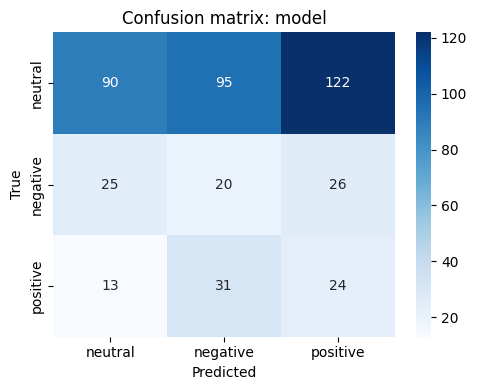

{'epoch': 1, 'train_loss': 1.0884714126586914, 'train_acc': 0.417607223476298, 'train_f1': 0.41815598389830977, 'val_acc': 0.3004484304932735, 'val_f1': 0.2660416335610996}
Saved best: /content/eeem068_msctd_project/models/face_resnet18_augmented.pt


face_resnet18_augmented epoch 2/3 train:   0%|          | 0/28 [00:00<?, ?it/s]

Evaluate model:   0%|          | 0/14 [00:00<?, ?it/s]

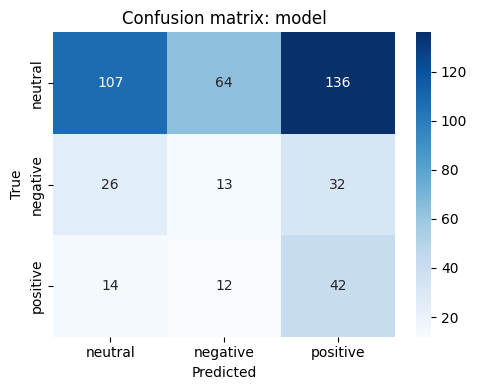

{'epoch': 2, 'train_loss': 0.9217526444367, 'train_acc': 0.554176072234763, 'train_f1': 0.5505043729478242, 'val_acc': 0.3632286995515695, 'val_f1': 0.3120079707159383}
Saved best: /content/eeem068_msctd_project/models/face_resnet18_augmented.pt


face_resnet18_augmented epoch 3/3 train:   0%|          | 0/28 [00:00<?, ?it/s]

Evaluate model:   0%|          | 0/14 [00:00<?, ?it/s]

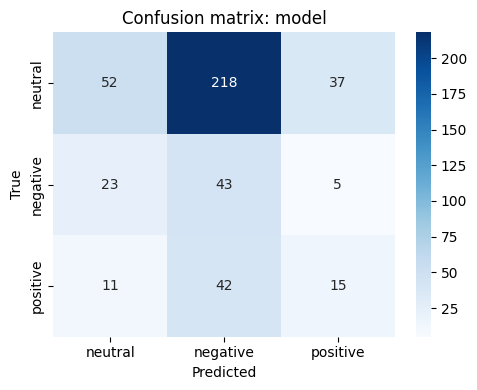

{'epoch': 3, 'train_loss': 0.7380272937672478, 'train_acc': 0.6749435665914221, 'train_f1': 0.6735690914506923, 'val_acc': 0.24663677130044842, 'val_f1': 0.24485918910705617}


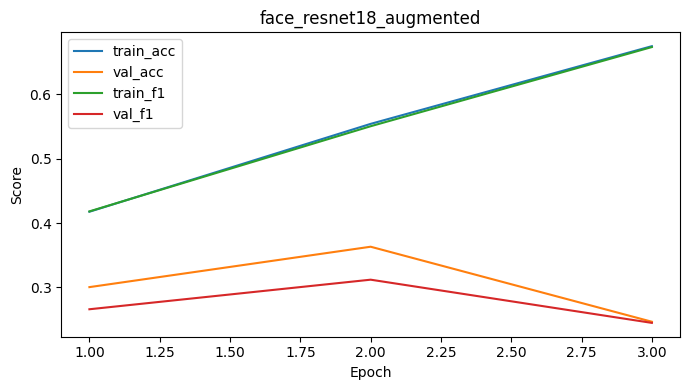

Augmented face model on original face test:


Evaluate face_aug_on_original:   0%|          | 0/14 [00:00<?, ?it/s]

Accuracy: 0.30385487528344673
Macro F1: 0.2999253461770018
              precision    recall  f1-score   support

     neutral       0.28      0.38      0.32       130
    negative       0.42      0.18      0.25       177
    positive       0.28      0.40      0.33       134

    accuracy                           0.30       441
   macro avg       0.33      0.32      0.30       441
weighted avg       0.34      0.30      0.29       441



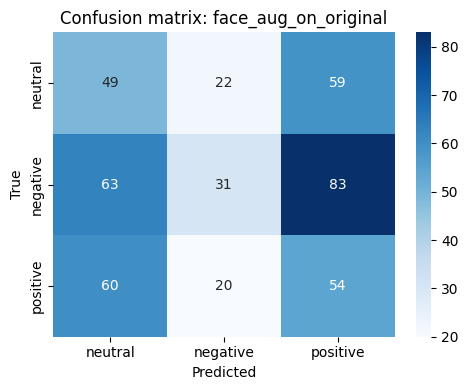

Augmented face model on degraded face test:


Evaluate face_aug_on_degraded:   0%|          | 0/14 [00:00<?, ?it/s]

Accuracy: 0.30839002267573695
Macro F1: 0.290517974970038
              precision    recall  f1-score   support

     neutral       0.30      0.48      0.37       130
    negative       0.44      0.10      0.16       177
    positive       0.29      0.42      0.34       134

    accuracy                           0.31       441
   macro avg       0.34      0.33      0.29       441
weighted avg       0.35      0.31      0.28       441



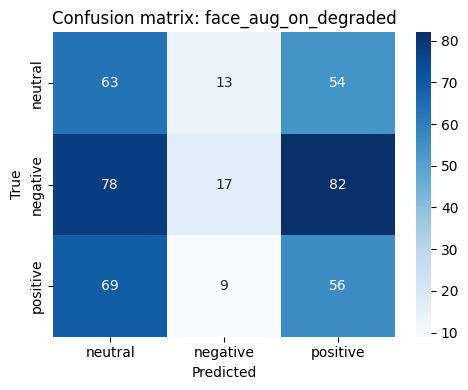

In [23]:
# =========================
# 11. Part 2/3: Retrain face model with original + degraded faces
# =========================
if RUN_AUGMENTATION_EXPERIMENT and len(face_train_clean) > 0:
    face_train_clean_augflag = face_train_clean.copy()
    face_train_clean_augflag["is_degraded"] = 0
    mixed_face_train = pd.concat([face_train_clean_augflag, degraded_face_train], ignore_index=True)
    mixed_face_train = mixed_face_train.sample(frac=1, random_state=SEED).reset_index(drop=True)

    mixed_train_ds = ImageSentimentDataset(mixed_face_train, path_col="face_path", transform=get_transforms(True))
    mixed_train_loader = DataLoader(mixed_train_ds, batch_size=BATCH_SIZE, sampler=make_weighted_sampler(mixed_face_train),
                                    num_workers=2, pin_memory=True)

    face_aug_model = build_resnet_classifier("resnet18", frozen=False)
    face_aug_model, face_aug_hist = train_model(face_aug_model, mixed_train_loader, face_val_loader,
                                                epochs=FACE_AUG_EPOCHS, lr=2e-4, model_name="face_resnet18_augmented")
    plot_history(face_aug_hist, "face_resnet18_augmented")

    print("Augmented face model on original face test:")
    face_aug_orig_metrics = evaluate_model(face_aug_model, face_test_loader, model_name="face_aug_on_original")

    print("Augmented face model on degraded face test:")
    face_aug_degraded_metrics = evaluate_model(face_aug_model, degraded_test_loader, model_name="face_aug_on_degraded")
else:
    print("Skipping augmented face retraining.")


## Part 3: Full-image feature model with frozen pretrained backbone

This section uses the full image and freezes the pretrained backbone, as required by the project specification.


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s]


full_image_frozen_resnet50 epoch 1/3 train:   0%|          | 0/17 [00:00<?, ?it/s]

Evaluate model:   0%|          | 0/16 [00:00<?, ?it/s]

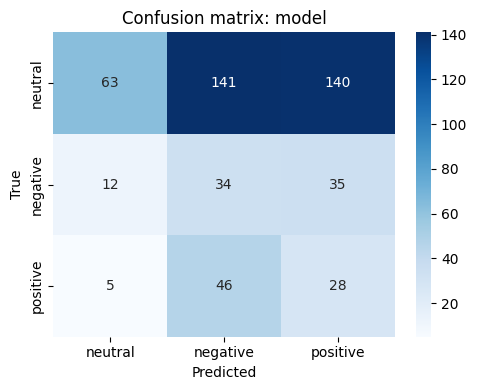

{'epoch': 1, 'train_loss': 1.1116674086626839, 'train_acc': 0.35271317829457366, 'train_f1': 0.3477693735615622, 'val_acc': 0.24801587301587302, 'val_f1': 0.24030564483944997}
Saved best: /content/eeem068_msctd_project/models/full_image_frozen_resnet50.pt


full_image_frozen_resnet50 epoch 2/3 train:   0%|          | 0/17 [00:00<?, ?it/s]

Evaluate model:   0%|          | 0/16 [00:00<?, ?it/s]

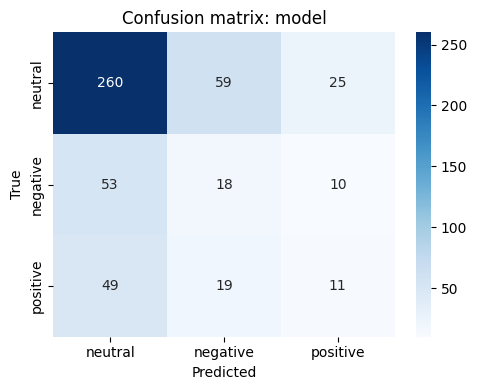

{'epoch': 2, 'train_loss': 1.028458090389476, 'train_acc': 0.48255813953488375, 'train_f1': 0.4820084576702027, 'val_acc': 0.5734126984126984, 'val_f1': 0.37197791328563884}
Saved best: /content/eeem068_msctd_project/models/full_image_frozen_resnet50.pt


full_image_frozen_resnet50 epoch 3/3 train:   0%|          | 0/17 [00:00<?, ?it/s]

Evaluate model:   0%|          | 0/16 [00:00<?, ?it/s]

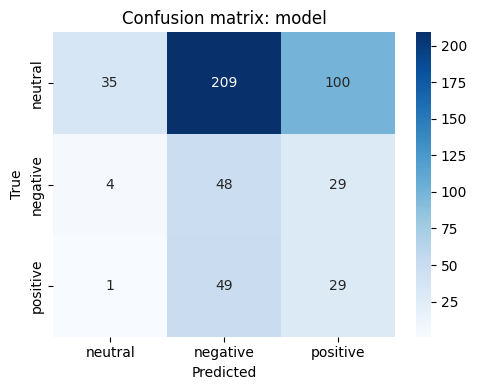

{'epoch': 3, 'train_loss': 1.0119094848632812, 'train_acc': 0.4941860465116279, 'train_f1': 0.49060013026122656, 'val_acc': 0.2222222222222222, 'val_f1': 0.22502647352238903}


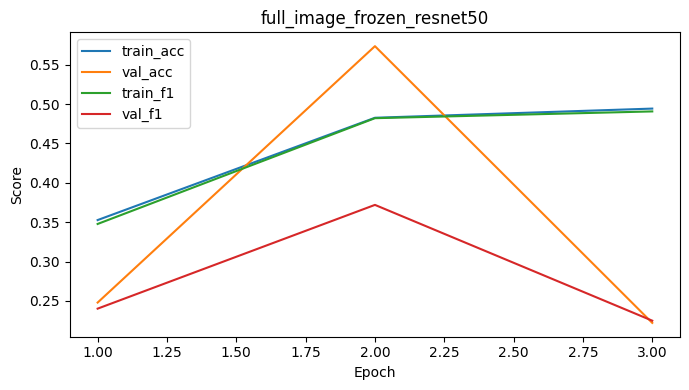

Evaluate full_image_frozen_resnet50:   0%|          | 0/16 [00:00<?, ?it/s]

Accuracy: 0.29273084479371314
Macro F1: 0.23733668809213368
              precision    recall  f1-score   support

     neutral       0.29      0.70      0.41       153
    negative       0.35      0.17      0.23       206
    positive       0.18      0.05      0.07       150

    accuracy                           0.29       509
   macro avg       0.27      0.31      0.24       509
weighted avg       0.28      0.29      0.24       509



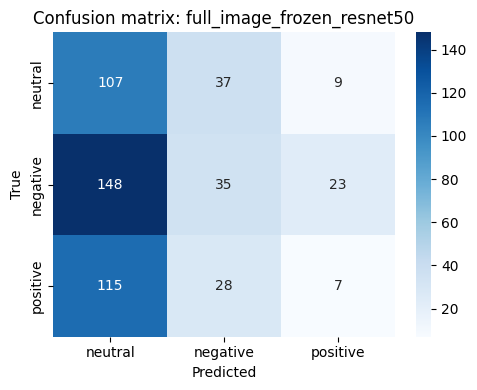

In [24]:
# =========================
# 12. Part 3: Full-image frozen ResNet50 model
# =========================
if RUN_FULL_IMAGE_MODEL:
    image_train_ds = ImageSentimentDataset(train_df, path_col="image_path", transform=get_transforms(True))
    image_val_ds = ImageSentimentDataset(val_df, path_col="image_path", transform=get_transforms(False))
    image_test_ds = ImageSentimentDataset(test_df, path_col="image_path", transform=get_transforms(False))

    image_train_loader = DataLoader(image_train_ds, batch_size=BATCH_SIZE, sampler=make_weighted_sampler(train_df),
                                    num_workers=2, pin_memory=True)
    image_val_loader = DataLoader(image_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    image_test_loader = DataLoader(image_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    full_image_model = build_resnet_classifier("resnet50", frozen=True)
    # Higher LR because only classifier head is trainable.
    full_image_model, image_hist = train_model(full_image_model, image_train_loader, image_val_loader,
                                               epochs=IMAGE_EPOCHS, lr=1e-3, model_name="full_image_frozen_resnet50")
    plot_history(image_hist, "full_image_frozen_resnet50")
    full_image_metrics = evaluate_model(full_image_model, image_test_loader, model_name="full_image_frozen_resnet50")
else:
    print("Skipping full-image model.")


## Part 4: Fusion model

The fusion model uses:

- face-model probabilities,
- full-image model probabilities,
- number of detected faces.

Final feature vector:

`[face_neg, face_neu, face_pos, image_neg, image_neu, image_pos, n_faces]`


In [25]:
# =========================
# 13. Feature extraction for fusion model
# =========================
@torch.no_grad()
def predict_probs_for_paths(model, df, path_col, batch_size=64, fallback_probs=None):
    model.eval()
    probs_all = np.zeros((len(df), NUM_CLASSES), dtype=np.float32)
    valid_indices = []
    valid_rows = []
    for idx, row in df.iterrows():
        p = row.get(path_col)
        if isinstance(p, str) and Path(p).exists():
            valid_indices.append(idx)
            valid_rows.append(row)
    if not valid_rows:
        if fallback_probs is None:
            fallback_probs = np.ones(NUM_CLASSES) / NUM_CLASSES
        return np.tile(fallback_probs, (len(df),1))
    valid_df = pd.DataFrame(valid_rows).reset_index(drop=True)
    ds = ImageSentimentDataset(valid_df, path_col=path_col, transform=get_transforms(False))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
    probs = []
    for x, y in tqdm(loader, desc=f"Predict {path_col}"):
        x = x.to(DEVICE)
        logits = model(x)
        probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    probs = np.vstack(probs)

    # default fallback = class prior from training data
    if fallback_probs is None:
        counts = train_df["label"].value_counts().reindex([0,1,2]).fillna(1).values.astype(np.float32)
        fallback_probs = counts / counts.sum()
    probs_all[:] = fallback_probs
    for j, original_idx in enumerate(valid_indices):
        probs_all[original_idx] = probs[j]
    return probs_all

def build_fusion_table(base_df, face_meta_df, split_name):
    # Align by orig_index where possible.
    fm = face_meta_df.copy().reset_index(drop=True)
    # For image model, use original image paths.
    img_probs = predict_probs_for_paths(full_image_model, base_df.reset_index(drop=True), "image_path", batch_size=64)
    face_probs = predict_probs_for_paths(face_aug_model if 'face_aug_model' in globals() else face_model,
                                         fm, "face_path", batch_size=64)
    n_faces = fm["n_faces"].fillna(0).values.reshape(-1,1).astype(np.float32)
    n_faces_scaled = np.clip(n_faces, 0, 5) / 5.0
    X = np.hstack([face_probs, img_probs, n_faces_scaled]).astype(np.float32)
    y = base_df["label"].values.astype(np.int64)
    return X, y

if RUN_FUSION_MODEL:
    X_train_fus, y_train_fus = build_fusion_table(train_df, face_train_df, "train")
    X_val_fus, y_val_fus = build_fusion_table(val_df, face_val_df, "dev")
    X_test_fus, y_test_fus = build_fusion_table(test_df, face_test_df, "test")

    print(X_train_fus.shape, y_train_fus.shape)


Predict image_path:   0%|          | 0/9 [00:00<?, ?it/s]

Predict face_path:   0%|          | 0/7 [00:10<?, ?it/s]

Predict image_path:   0%|          | 0/8 [00:00<?, ?it/s]

Predict face_path:   0%|          | 0/7 [00:00<?, ?it/s]

Predict image_path:   0%|          | 0/8 [00:00<?, ?it/s]

Predict face_path:   0%|          | 0/7 [00:00<?, ?it/s]

(516, 7) (516,)


fusion_val Accuracy: 0.15674603174603174 Macro F1: 0.09832026875699888
              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00       344
    negative       0.08      0.01      0.02        81
    positive       0.16      0.99      0.27        79

    accuracy                           0.16       504
   macro avg       0.08      0.33      0.10       504
weighted avg       0.04      0.16      0.05       504

{'epoch': 1, 'loss': 1.107076358795166, 'val_acc': 0.15674603174603174, 'val_f1': 0.09832026875699888}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


fusion_val Accuracy: 0.15674603174603174 Macro F1: 0.0903373356203545
              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00       344
    negative       0.00      0.00      0.00        81
    positive       0.16      1.00      0.27        79

    accuracy                           0.16       504
   macro avg       0.05      0.33      0.09       504
weighted avg       0.02      0.16      0.04       504

{'epoch': 2, 'loss': 1.0894047021865845, 'val_acc': 0.15674603174603174, 'val_f1': 0.0903373356203545}
fusion_val Accuracy: 0.15674603174603174 Macro F1: 0.0903373356203545
              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00       344
    negative       0.00      0.00      0.00        81
    positive       0.16      1.00      0.27        79

    accuracy                           0.16       504
   macro avg       0.05      0.33      0.09       504
weighted avg       0.02      0.16      0.04       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00       344
    negative       0.00      0.00      0.00        81
    positive       0.16      1.00      0.27        79

    accuracy                           0.16       504
   macro avg       0.05      0.33      0.09       504
weighted avg       0.02      0.16      0.04       504

{'epoch': 6, 'loss': 1.0396907925605774, 'val_acc': 0.15674603174603174, 'val_f1': 0.0903373356203545}
fusion_val Accuracy: 0.15674603174603174 Macro F1: 0.0903373356203545
              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00       344
    negative       0.00      0.00      0.00        81
    positive       0.16      1.00      0.27        79

    accuracy                           0.16       504
   macro avg       0.05      0.33      0.09       504
weighted avg       0.02      0.16      0.04       504

{'epoch': 7, 'loss': 1.0557710170745849, 'val_acc': 0.15674603174

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

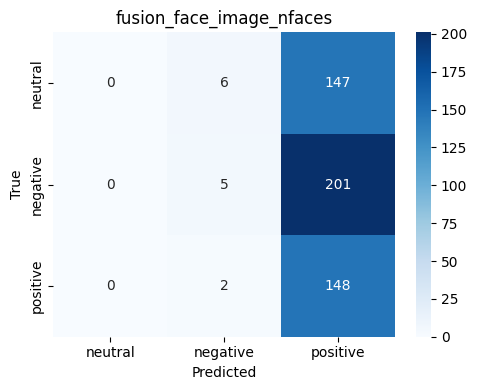

In [26]:
# =========================
# 14. Train fusion MLP
# =========================
class FusionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class FusionMLP(nn.Module):
    def __init__(self, in_dim=7, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def train_fusion_model(X_train, y_train, X_val, y_val, epochs=10):
    train_loader = DataLoader(FusionDataset(X_train, y_train), batch_size=128, shuffle=True)
    val_loader = DataLoader(FusionDataset(X_val, y_val), batch_size=256, shuffle=False)
    model = FusionMLP(in_dim=X_train.shape[1]).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    best_f1 = -1
    best_path = MODEL_DIR / "fusion_mlp.pt"
    hist = []
    for epoch in range(1, epochs+1):
        model.train()
        losses = []
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        val_metrics = eval_fusion_model(model, X_val, y_val, name="fusion_val", plot=False)
        row = {"epoch":epoch, "loss":np.mean(losses), "val_acc":val_metrics["accuracy"], "val_f1":val_metrics["macro_f1"]}
        hist.append(row)
        print(row)
        if row["val_f1"] > best_f1:
            best_f1 = row["val_f1"]
            torch.save(model.state_dict(), best_path)
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    pd.DataFrame(hist).to_csv(RESULT_DIR / "fusion_history.csv", index=False)
    return model, pd.DataFrame(hist)

@torch.no_grad()
def eval_fusion_model(model, X, y, name="fusion", plot=True):
    model.eval()
    loader = DataLoader(FusionDataset(X, y), batch_size=256, shuffle=False)
    probs = []
    labels = []
    for x, yy in loader:
        x = x.to(DEVICE)
        p = torch.softmax(model(x), dim=1).cpu().numpy()
        probs.append(p)
        labels.extend(yy.numpy())
    probs = np.vstack(probs)
    labels = np.array(labels)
    preds = probs.argmax(1)
    print(name, "Accuracy:", accuracy_score(labels, preds), "Macro F1:", f1_score(labels, preds, average="macro"))
    print(classification_report(labels, preds, target_names=[LABEL_MAP[i] for i in range(NUM_CLASSES)]))
    if plot:
        cm = confusion_matrix(labels, preds, labels=[0,1,2])
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=[LABEL_MAP[i] for i in range(NUM_CLASSES)],
                    yticklabels=[LABEL_MAP[i] for i in range(NUM_CLASSES)])
        plt.title(name)
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.savefig(RESULT_DIR / f"{name}_confusion_matrix.png", dpi=200)
        plt.show()
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "probs": probs,
        "preds": preds,
        "labels": labels
    }

if RUN_FUSION_MODEL:
    fusion_model, fusion_hist = train_fusion_model(X_train_fus, y_train_fus, X_val_fus, y_val_fus, epochs=FUSION_EPOCHS)
    fusion_metrics = eval_fusion_model(fusion_model, X_test_fus, y_test_fus, name="fusion_face_image_nfaces")


## Extra credit: Multimodal Transformer-style text + image fusion

This model is designed to improve accuracy by using English text plus image information.

Implementation:

- Text encoder: DistilBERT.
- Image encoder: ResNet18.
- Fusion: concatenate text embedding + image embedding.
- Classifier: MLP.
- Stable fine-tuning: freeze most layers at first, train only projection/classifier by default.

For stronger final results:
- Set `FREEZE_TEXT = False` after one stable run.
- Increase `MULTIMODAL_EPOCHS`.
- Use the full dataset.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

distilbert_resnet18_fusion_frozen_val Accuracy: 0.16865079365079366 Macro F1: 0.10921409214092141
              precision    recall  f1-score   support

     neutral       0.83      0.01      0.03       344
    negative       0.33      0.01      0.02        81
    positive       0.16      1.00      0.28        79

    accuracy                           0.17       504
   macro avg       0.44      0.34      0.11       504
weighted avg       0.65      0.17      0.07       504

{'epoch': 2, 'train_loss': 1.0575034401633523, 'train_acc': 0.4476744186046512, 'train_f1': 0.26622704195159497, 'val_acc': 0.16865079365079366, 'val_f1': 0.10921409214092141}


distilbert_resnet18_fusion_frozen epoch 3/3 train:   0%|          | 0/33 [00:00<?, ?it/s]

Evaluate distilbert_resnet18_fusion_frozen_val:   0%|          | 0/16 [00:00<?, ?it/s]

distilbert_resnet18_fusion_frozen_val Accuracy: 0.5357142857142857 Macro F1: 0.4534973409653716
              precision    recall  f1-score   support

     neutral       0.85      0.55      0.67       344
    negative       0.47      0.22      0.30        81
    positive       0.26      0.80      0.39        79

    accuracy                           0.54       504
   macro avg       0.53      0.52      0.45       504
weighted avg       0.70      0.54      0.56       504

{'epoch': 3, 'train_loss': 1.0355881199692234, 'train_acc': 0.437984496124031, 'train_f1': 0.3475675200915591, 'val_acc': 0.5357142857142857, 'val_f1': 0.4534973409653716}


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7beef86c4900>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1479, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1443, in _shutdown_workers
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
  File "/usr/lib/python3.12/selectors.py", line 415, in select
KeyboardInterrupt: 


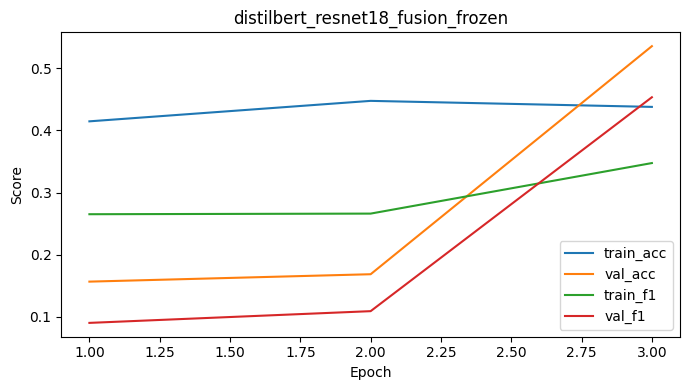

Evaluate distilbert_resnet18_fusion_frozen:   0%|          | 0/16 [00:00<?, ?it/s]

distilbert_resnet18_fusion_frozen Accuracy: 0.4066797642436149 Macro F1: 0.3811526884728953
              precision    recall  f1-score   support

     neutral       0.42      0.65      0.51       153
    negative       0.71      0.12      0.21       206
    positive       0.35      0.55      0.43       150

    accuracy                           0.41       509
   macro avg       0.49      0.44      0.38       509
weighted avg       0.52      0.41      0.36       509



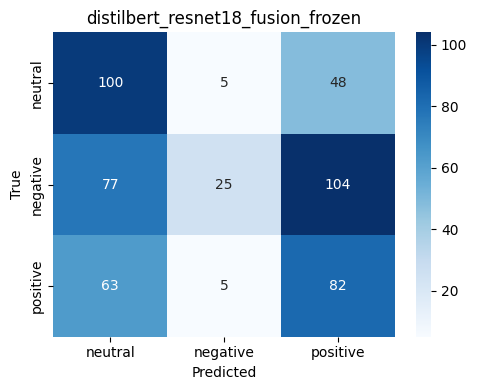

In [27]:
# =========================
# 15. Extra Credit: Multimodal text + image model
# =========================
class MultimodalDataset(Dataset):
    def __init__(self, df, tokenizer, transform=None, max_length=64):
        self.df = df.copy().reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_length = max_length
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row["text"])
        enc = self.tokenizer(text, truncation=True, padding="max_length",
                             max_length=self.max_length, return_tensors="pt")
        img = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        y = int(row["label"])
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "image": img,
            "label": torch.tensor(y, dtype=torch.long)
        }

class TextImageFusionModel(nn.Module):
    def __init__(self, text_model_name="distilbert-base-uncased", freeze_text=True, freeze_image=True):
        super().__init__()
        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        text_dim = self.text_encoder.config.hidden_size

        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        img_dim = resnet.fc.in_features
        resnet.fc = nn.Identity()
        self.image_encoder = resnet

        if freeze_text:
            for p in self.text_encoder.parameters():
                p.requires_grad = False
        if freeze_image:
            for p in self.image_encoder.parameters():
                p.requires_grad = False

        self.text_proj = nn.Sequential(nn.Linear(text_dim, 256), nn.ReLU(), nn.Dropout(0.2))
        self.img_proj = nn.Sequential(nn.Linear(img_dim, 256), nn.ReLU(), nn.Dropout(0.2))
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(256, NUM_CLASSES)
        )
    def forward(self, input_ids, attention_mask, image):
        txt_out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        # DistilBERT has no pooler output. Use [CLS] token.
        txt = txt_out.last_hidden_state[:, 0, :]
        img = self.image_encoder(image)
        txt = self.text_proj(txt)
        img = self.img_proj(img)
        fused = torch.cat([txt, img], dim=1)
        return self.classifier(fused)

def train_multimodal(model, train_loader, val_loader, epochs=3, lr=2e-4, name="multimodal"):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))
    best_f1 = -1
    best_path = MODEL_DIR / f"{name}.pt"
    hist = []
    for epoch in range(1, epochs+1):
        model.train()
        losses, preds, labels = [], [], []
        for batch in tqdm(train_loader, desc=f"{name} epoch {epoch}/{epochs} train"):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            image = batch["image"].to(DEVICE)
            y = batch["label"].to(DEVICE)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):
                logits = model(input_ids, attention_mask, image)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            losses.append(loss.item())
            preds.extend(logits.argmax(1).detach().cpu().numpy())
            labels.extend(y.cpu().numpy())

        val_metrics = eval_multimodal(model, val_loader, name=f"{name}_val", plot=False)
        row = {
            "epoch": epoch,
            "train_loss": np.mean(losses),
            "train_acc": accuracy_score(labels, preds),
            "train_f1": f1_score(labels, preds, average="macro"),
            "val_acc": val_metrics["accuracy"],
            "val_f1": val_metrics["macro_f1"]
        }
        hist.append(row)
        print(row)
        if row["val_f1"] > best_f1:
            best_f1 = row["val_f1"]
            torch.save(model.state_dict(), best_path)
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    hist = pd.DataFrame(hist)
    hist.to_csv(RESULT_DIR / f"{name}_history.csv", index=False)
    return model, hist

@torch.no_grad()
def eval_multimodal(model, loader, name="multimodal", plot=True):
    model.eval()
    probs, labels = [], []
    for batch in tqdm(loader, desc=f"Evaluate {name}"):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        image = batch["image"].to(DEVICE)
        y = batch["label"].numpy()
        logits = model(input_ids, attention_mask, image)
        probs.append(torch.softmax(logits, dim=1).cpu().numpy())
        labels.extend(y)
    probs = np.vstack(probs)
    labels = np.array(labels)
    preds = probs.argmax(1)
    print(name, "Accuracy:", accuracy_score(labels, preds), "Macro F1:", f1_score(labels, preds, average="macro"))
    print(classification_report(labels, preds, target_names=[LABEL_MAP[i] for i in range(NUM_CLASSES)]))
    if plot:
        cm = confusion_matrix(labels, preds, labels=[0,1,2])
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=[LABEL_MAP[i] for i in range(NUM_CLASSES)],
                    yticklabels=[LABEL_MAP[i] for i in range(NUM_CLASSES)])
        plt.title(name)
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.savefig(RESULT_DIR / f"{name}_confusion_matrix.png", dpi=200)
        plt.show()
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "probs": probs,
        "preds": preds,
        "labels": labels
    }

if RUN_MULTIMODAL_EXTRA_CREDIT:
    tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
    mm_train_ds = MultimodalDataset(train_df, tokenizer, transform=get_transforms(True), max_length=64)
    mm_val_ds = MultimodalDataset(val_df, tokenizer, transform=get_transforms(False), max_length=64)
    mm_test_ds = MultimodalDataset(test_df, tokenizer, transform=get_transforms(False), max_length=64)

    mm_train_loader = DataLoader(mm_train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
    mm_val_loader = DataLoader(mm_val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
    mm_test_loader = DataLoader(mm_test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    # Stable first run: freeze encoders, train fusion head.
    # For stronger final run, try freeze_text=False and freeze_image=False with lr=2e-5.
    multimodal_model = TextImageFusionModel(
        text_model_name="distilbert-base-uncased",
        freeze_text=True,
        freeze_image=True
    ).to(DEVICE)

    multimodal_model, mm_hist = train_multimodal(multimodal_model, mm_train_loader, mm_val_loader,
                                                 epochs=MULTIMODAL_EPOCHS, lr=5e-4, name="distilbert_resnet18_fusion_frozen")
    plot_history(mm_hist.rename(columns={"val_f1":"val_f1", "train_f1":"train_f1"}), "distilbert_resnet18_fusion_frozen")
    mm_metrics = eval_multimodal(multimodal_model, mm_test_loader, name="distilbert_resnet18_fusion_frozen")


## Optional stronger multimodal fine-tuning

Run this only after the frozen multimodal model works. It partially unfreezes the last text layers and the last ResNet block. This can improve performance but takes longer and may overfit.


In [28]:
# =========================
# 16. Optional: stronger fine-tuning after stable frozen run
# =========================
RUN_STRONG_MULTIMODAL_FINETUNE = False  # change to True for final run if time/GPU allows

if RUN_STRONG_MULTIMODAL_FINETUNE and RUN_MULTIMODAL_EXTRA_CREDIT:
    strong_model = TextImageFusionModel(
        text_model_name="distilbert-base-uncased",
        freeze_text=True,
        freeze_image=True
    ).to(DEVICE)

    # Start from previous model weights
    strong_model.load_state_dict(torch.load(MODEL_DIR / "distilbert_resnet18_fusion_frozen.pt", map_location=DEVICE), strict=False)

    # Unfreeze last DistilBERT transformer block
    for p in strong_model.text_encoder.transformer.layer[-1].parameters():
        p.requires_grad = True

    # Unfreeze ResNet layer4
    for p in strong_model.image_encoder.layer4.parameters():
        p.requires_grad = True

    strong_model, strong_hist = train_multimodal(
        strong_model, mm_train_loader, mm_val_loader,
        epochs=3 if FAST_MODE else 5,
        lr=2e-5,
        name="distilbert_resnet18_fusion_partial_finetune"
    )
    strong_metrics = eval_multimodal(strong_model, mm_test_loader, name="distilbert_resnet18_fusion_partial_finetune")


## Result summary table

Use this table directly in the report.


In [29]:
# =========================
# 17. Summarise all available results
# =========================
summary_rows = []

def add_result(name, metrics):
    if metrics is None:
        return
    summary_rows.append({
        "Model": name,
        "Accuracy": round(float(metrics["accuracy"]), 4),
        "Macro F1": round(float(metrics["macro_f1"]), 4),
        "Weighted F1": round(float(metrics["weighted_f1"]), 4),
    })

for var_name, pretty_name in [
    ("face_metrics", "Face ResNet18"),
    ("degraded_face_metrics", "Face ResNet18 on degraded faces"),
    ("face_aug_orig_metrics", "Augmented Face ResNet18 on original faces"),
    ("face_aug_degraded_metrics", "Augmented Face ResNet18 on degraded faces"),
    ("full_image_metrics", "Full-image frozen ResNet50"),
    ("fusion_metrics", "Fusion: face + image + n_faces"),
    ("mm_metrics", "Extra credit: DistilBERT + ResNet18 fusion"),
    ("strong_metrics", "Extra credit: partial fine-tuned fusion"),
]:
    if var_name in globals():
        add_result(pretty_name, globals()[var_name])

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(RESULT_DIR / "final_results_summary.csv", index=False)
print("Saved:", RESULT_DIR / "final_results_summary.csv")


,Model,Accuracy,Macro F1,Weighted F1
0,Face ResNet18,0.3696,0.3469,0.3597
1,Face ResNet18 on degraded faces,0.3401,0.3084,0.3230
2,Augmented Face ResNet18 on original faces,0.3039,0.2999,0.2946
3,Augmented Face ResNet18 on degraded faces,0.3084,0.2905,0.2768
4,Full-image frozen ResNet50,0.2927,0.2373,0.2374
5,Fusion: face + image + n_faces,0.3006,0.1680,0.1535
6,Extra credit: DistilBERT + ResNet18 fusion,0.4067,0.3812,0.3628


Saved: /content/eeem068_msctd_project/results/final_results_summary.csv


## Save notebook outputs for report

The `results` folder contains:

- class distribution plot,
- sample images,
- training curves,
- confusion matrices,
- final results CSV.

Download the folder as a ZIP after running the notebook.


In [30]:
# =========================
# 18. Zip models/results for submission/report
# =========================
%cd {PROJECT_DIR}
!zip -r -q eeem068_results_and_models.zip results models cache/*.csv || true
print("Created:", PROJECT_DIR / "eeem068_results_and_models.zip")


/content/eeem068_msctd_project
Created: /content/eeem068_msctd_project/eeem068_results_and_models.zip


# How to improve accuracy for final run

Use this order:

1. Run the notebook once with `FAST_MODE = True` to confirm everything works.
2. Set `FAST_MODE = False`.
3. Use Colab GPU.
4. Increase:
   - `MULTIMODAL_EPOCHS = 5`
   - `IMAGE_EPOCHS = 8`
   - `FACE_EPOCHS = 8`
5. Run optional partial multimodal fine-tuning.
6. Report all models honestly. The multimodal model is expected to outperform image-only models because text carries clearer sentiment cues.

# Suggested report table

| Model | Input | Backbone | Accuracy | Macro F1 |
|---|---|---|---:|---:|
| Face ResNet18 | Cropped face | ResNet18 | generated | generated |
| Degraded face test | Cropped degraded face | ResNet18 | generated | generated |
| Augmented face model | Face + degraded face | ResNet18 | generated | generated |
| Full image | Whole image | Frozen ResNet50 | generated | generated |
| Fusion | Face prob + image prob + face count | MLP | generated | generated |
| Extra credit multimodal | English text + image | DistilBERT + ResNet18 | generated | generated |
